part6 Transfer Learning with ResNet18

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
#creat model
from models.resnet18 import create_resnet18

model = create_resnet18()

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [3]:
#Check trainable parameters
trainable = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel() for p in model.parameters()
)

print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")

Trainable Parameters : 52,326
Total Parameters     : 11,228,838


In [4]:
#Device
from config import DEVICE

model = model.to(DEVICE)

In [5]:
#Optimizer
import torch.optim as optim

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [6]:
#Loss
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [7]:
#Scheduler
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

In [8]:
from utils.train import train_one_epoch, evaluate

In [9]:
from utils.dataloader import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders()

In [15]:
#Training loop
import torch
num_epochs = 10
train_losses = []
val_losses = []

train_accs = []
val_accs = []

results = []

best_acc = 0

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    results.append({
        "Epoch": epoch + 1,
        "Train Loss": train_loss,
        "Validation Loss": val_loss,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc
    })

    print(
        f"Epoch {epoch+1}/{num_epochs}"
        f" | Train Loss {train_loss:.4f}"
        f" | Train Acc {train_acc:.4f}"
        f" | Val Loss {val_loss:.4f}"
        f" | Val Acc {val_acc:.4f}"
    )

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "../weights/best_resnet18.pth")
        print("✅ Best model saved.")

Epoch 1/10 | Train Loss 2.4262 | Train Acc 0.4931 | Val Loss 2.1160 | Val Acc 0.6559
✅ Best model saved.
Epoch 2/10 | Train Loss 2.3691 | Train Acc 0.5157 | Val Loss 2.0990 | Val Acc 0.6520
Epoch 3/10 | Train Loss 2.3509 | Train Acc 0.5000 | Val Loss 2.0190 | Val Acc 0.6578
✅ Best model saved.
Epoch 4/10 | Train Loss 2.3125 | Train Acc 0.5206 | Val Loss 2.0007 | Val Acc 0.6667
✅ Best model saved.
Epoch 5/10 | Train Loss 2.2499 | Train Acc 0.5520 | Val Loss 1.9875 | Val Acc 0.6706
✅ Best model saved.
Epoch 6/10 | Train Loss 2.2636 | Train Acc 0.5098 | Val Loss 1.9553 | Val Acc 0.6716
✅ Best model saved.
Epoch 7/10 | Train Loss 2.2513 | Train Acc 0.5343 | Val Loss 1.9242 | Val Acc 0.6794
✅ Best model saved.
Epoch 8/10 | Train Loss 2.2470 | Train Acc 0.5206 | Val Loss 1.9315 | Val Acc 0.6814
✅ Best model saved.
Epoch 9/10 | Train Loss 2.2487 | Train Acc 0.5196 | Val Loss 1.9170 | Val Acc 0.6814
Epoch 10/10 | Train Loss 2.1749 | Train Acc 0.5343 | Val Loss 1.8853 | Val Acc 0.6863
✅ Best mo

In [16]:
#save results
from utils.save_results import save_training_results

df = save_training_results(
    results,
    "resnet18_results.csv"
)

✅ Results saved to ..\results\resnet18_results.csv


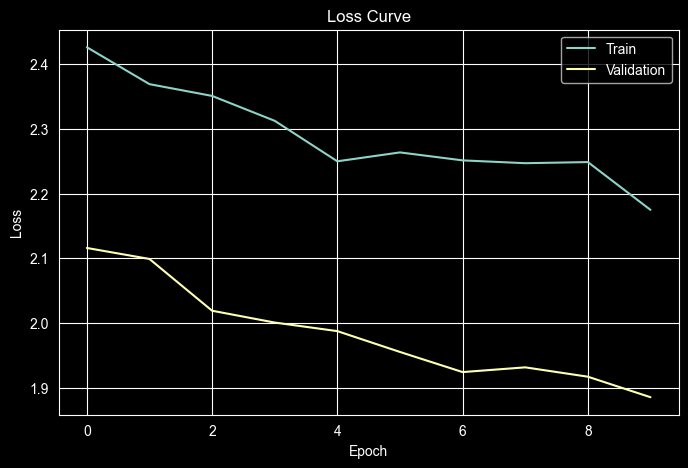

In [17]:
#Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

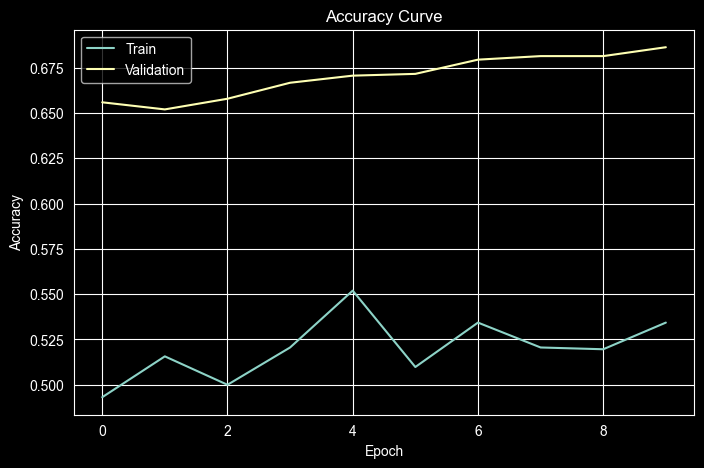

In [18]:
#Accuracy curve
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()